In [6]:
import matplotlib.pyplot as plt
import simpy

from asyncflow import AsyncFlow
from asyncflow.components import Server, Edge, Client, LoadBalancer, Endpoint
from asyncflow.settings import SimulationSettings
from asyncflow.workload import RqsGenerator

# Runner + Analyzer
from asyncflow.metrics.simulation_analyzer import ResultsAnalyzer
from asyncflow.runner.simulation import SimulationRunner


# Scenario payload: LB + 2 servers with faults and network spikes

This notebook uses a single, self-contained payload that models a small web service under changing network and capacity conditions.

## What the payload contains

* **Workload (RqsGenerator)**

  * `avg_active_users=120`, `avg_request_per_minute_per_user=20`, `user_sampling_window=60s`.
  * ≈ **40 RPS** on average (piecewise-constant across 60-second windows).

* **Client**

  * One client node (`client-1`) as the traffic origin/terminus.

* **Servers (two identical replicas)**

  * `srv-1`, `srv-2`, each with `cpu_cores=1`, `ram_mb=2048`.
  * One endpoint `/api` with **CPU 2 ms → RAM 128 MB → I/O 12 ms**.

    * `initial_parsing` (CPU-bound): 0.002 s
    * `ram` reservation: 128 MB
    * `io_wait`: 0.012 s

* **Load balancer**

  * `lb-1` with **round\_robin** dispatch, covering `srv-1` and `srv-2`.

* **Network edges (stochastic)**

  * All links use **exponential latency** (means shown in code):
    `gen→client` 3 ms, `client→lb` 2 ms, `lb→srv*` 2 ms, `srv*→client` 3 ms.

* **Simulation settings**

  * `total_simulation_time=600 s`, `sample_period_s=0.05 s`.
  * Sampled metrics enabled: `ready_queue_len`, `event_loop_io_sleep`, `ram_in_use`,
    `edge_concurrent_connection`.
  * Event metrics enabled: `rqs_clock`.

## Injected events (timeline)

* **t = 100–160 s:** +15 ms **network spike** on `client→lb`.
* **t = 180–240 s:** **Server outage** — `srv-1` down (all traffic shifts to `srv-2`).
* **t = 300–360 s:** +20 ms **network spike** on `lb→srv-2`.
* **t = 360–420 s:** **Server outage** — `srv-2` down (all traffic shifts to `srv-1`).
* **t = 480–540 s:** +10 ms **network spike** on `gen→client`.

## What this scenario highlights

* Impact of **pure edge latency** spikes on end-to-end latency (with capacity unchanged).
* Impact of **capacity loss** (one replica down) on queues, waiting time, and throughput.
* Interaction of both effects when spikes and outages overlap different parts of the path.
* Per-server views of **ready queue**, **I/O waiting**, and **RAM in use** as conditions change.


In [7]:
def build_and_run() -> ResultsAnalyzer:
    """Build the scenario via the builder and run the simulation."""
    # ── Workload (generator) ───────────────────────────────────────────────
    generator = RqsGenerator(
        id="rqs-1",
        avg_active_users={"mean": 120},
        avg_request_per_minute_per_user={"mean": 20},
        user_sampling_window=60,
    )

    # ── Client ────────────────────────────────────────────────────────────
    client = Client(id="client-1")

    # ── Servers (identical endpoint: CPU 2ms → RAM 128MB → IO 12ms) ───────
    endpoint = Endpoint(
    endpoint_name="/api",
    steps=[
        {
            "kind": "initial_parsing",
            "step_operation": {
                "cpu_time": {"mean": 0.012, "distribution": "exponential"},
            },
        },
        {
            "kind": "ram",
            "step_operation": {"necessary_ram": 128},  # resource reservation (no time RV)
        },
        {
            "kind": "io_wait",
            "step_operation": {
                "io_waiting_time": {"mean": 0.012, "distribution": "exponential"},
            },
        },
    ],
)
    srv1 = Server(
        id="srv-1",
        server_resources={"cpu_cores": 1, "ram_mb": 2048},
        endpoints=[endpoint],
    )
    srv2 = Server(
        id="srv-2",
        server_resources={"cpu_cores": 1, "ram_mb": 2048},
        endpoints=[endpoint],
    )

    # ── Load Balancer ─────────────────────────────────────────────────────
    lb = LoadBalancer(
        id="lb-1",
        algorithms="round_robin",
        server_covered=["srv-1", "srv-2"],
    )

    # ── Edges (exponential latency) ───────────────────────────────────────
    e_gen_client = Edge(
        id="gen-client",
        source="rqs-1",
        target="client-1",
        latency={"mean": 0.003, "distribution": "exponential"},
    )
    e_client_lb = Edge(
        id="client-lb",
        source="client-1",
        target="lb-1",
        latency={"mean": 0.002, "distribution": "exponential"},
    )
    e_lb_srv1 = Edge(
        id="lb-srv1",
        source="lb-1",
        target="srv-1",
        latency={"mean": 0.002, "distribution": "exponential"},
    )
    e_lb_srv2 = Edge(
        id="lb-srv2",
        source="lb-1",
        target="srv-2",
        latency={"mean": 0.002, "distribution": "exponential"},
    )
    e_srv1_client = Edge(
        id="srv1-client",
        source="srv-1",
        target="client-1",
        latency={"mean": 0.003, "distribution": "exponential"},
    )
    e_srv2_client = Edge(
        id="srv2-client",
        source="srv-2",
        target="client-1",
        latency={"mean": 0.003, "distribution": "exponential"},
    )

    # ── Simulation settings ───────────────────────────────────────────────
    settings = SimulationSettings(
        total_simulation_time=600,
        sample_period_s=0.05,
        enabled_sample_metrics=[
            "ready_queue_len",
            "event_loop_io_sleep",
            "ram_in_use",
            "edge_concurrent_connection",
        ],
        enabled_event_metrics=["rqs_clock"],
    )

    # ── Assemble payload + events via builder ─────────────────────────────
    payload = (
        AsyncFlow()
        .add_generator(generator)
        .add_client(client)
        .add_servers(srv1, srv2)
        .add_load_balancer(lb)
        .add_edges(
            e_gen_client,
            e_client_lb,
            e_lb_srv1,
            e_lb_srv2,
            e_srv1_client,
            e_srv2_client,
        )
        .add_simulation_settings(settings)
        # Events
        .add_network_spike(
            event_id="ev-spike-1",
            edge_id="client-lb",
            t_start=100.0,
            t_end=160.0,
            spike_s=0.015,  # +15 ms
        )
        .add_server_outage(
            event_id="ev-srv1-down",
            server_id="srv-1",
            t_start=180.0,
            t_end=240.0,
        )
        .add_network_spike(
            event_id="ev-spike-2",
            edge_id="lb-srv2",
            t_start=300.0,
            t_end=360.0,
            spike_s=0.020,  # +20 ms
        )
        .add_server_outage(
            event_id="ev-srv2-down",
            server_id="srv-2",
            t_start=360.0,
            t_end=420.0,
        )
        .add_network_spike(
            event_id="ev-spike-3",
            edge_id="gen-client",
            t_start=480.0,
            t_end=540.0,
            spike_s=0.010,  # +10 ms
        )
        .build_payload()
    )
    
    env = simpy.Environment()
    runner = SimulationRunner(env=env, simulation_input=payload)
    results: ResultsAnalyzer = runner.run()
    
    return results

results = build_and_run()

### How to read the charts

This notebook plots **system-level** behavior and **per-server** metrics so you can quickly spot bottlenecks and the effect of injected events.

* **Latency distribution (left):** Histogram of end-to-end request latency. Vertical lines mark **mean**, **P50**, **P95**, **P99**. A right-hand tail indicates queuing or I/O bursts; shifts during event windows will move these lines to the right.

* **Throughput over time (right):** Windowed **requests/s** with points for each sampling window. Dashed horizontal lines show **mean**, **P95**, and **max**. Dips or plateaus often align with network spikes or server outages.

* **Per-server time series:**

  * **Ready queue:** number of requests waiting for a CPU core (compute contention).
  * **I/O queue:** requests blocked on I/O (back-end or network effects).
  * **RAM usage:** instantaneous reserved memory on the server.

* **Per-server event metrics (histograms):**

  * **Server latency:** time inside the server (queue + service).
  * **CPU service time:** sampled service durations (from the configured distribution).
  * **I/O time:** time spent waiting on I/O.
  * **CPU waiting time:** pure queueing before CPU starts.

**Tips:** look for coordinated moves across panels (e.g., throughput dips + latency/queues rising). Short, sharp spikes typically come from transient events; sustained shifts suggest capacity issues or saturation.


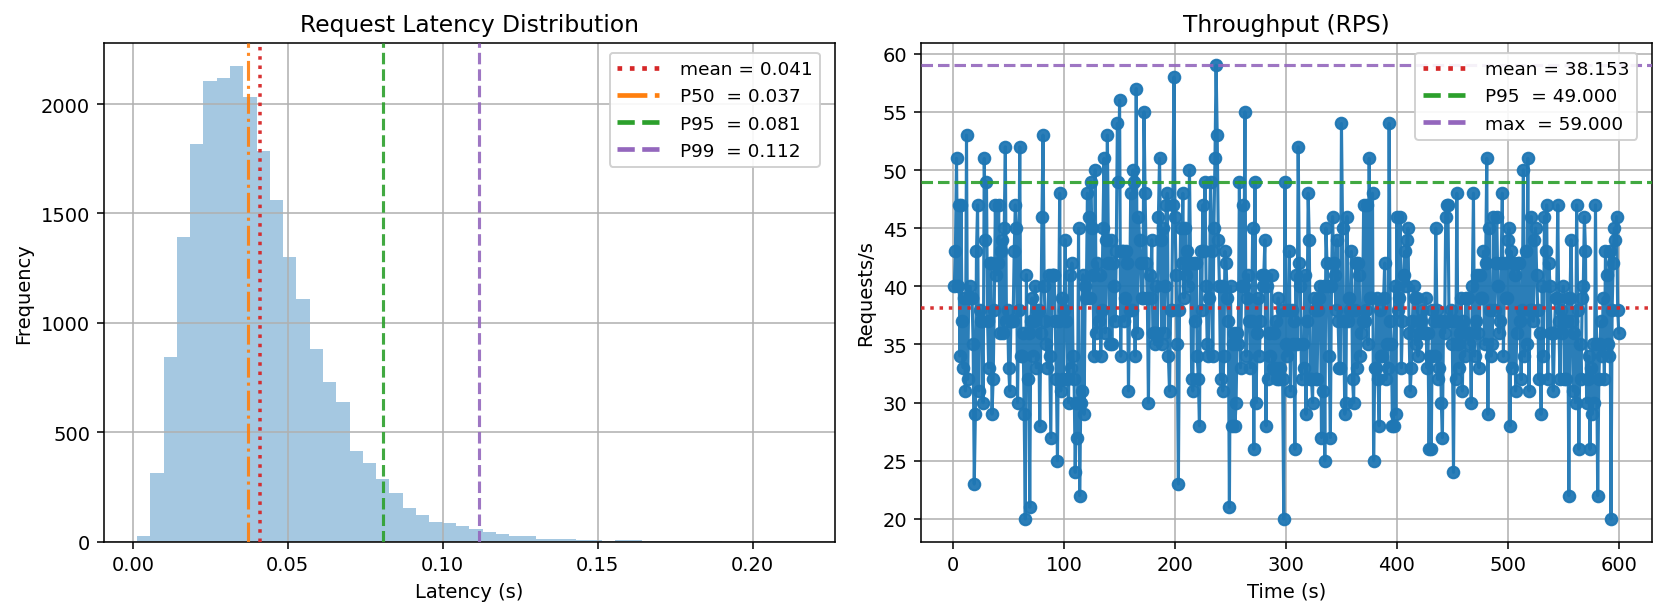

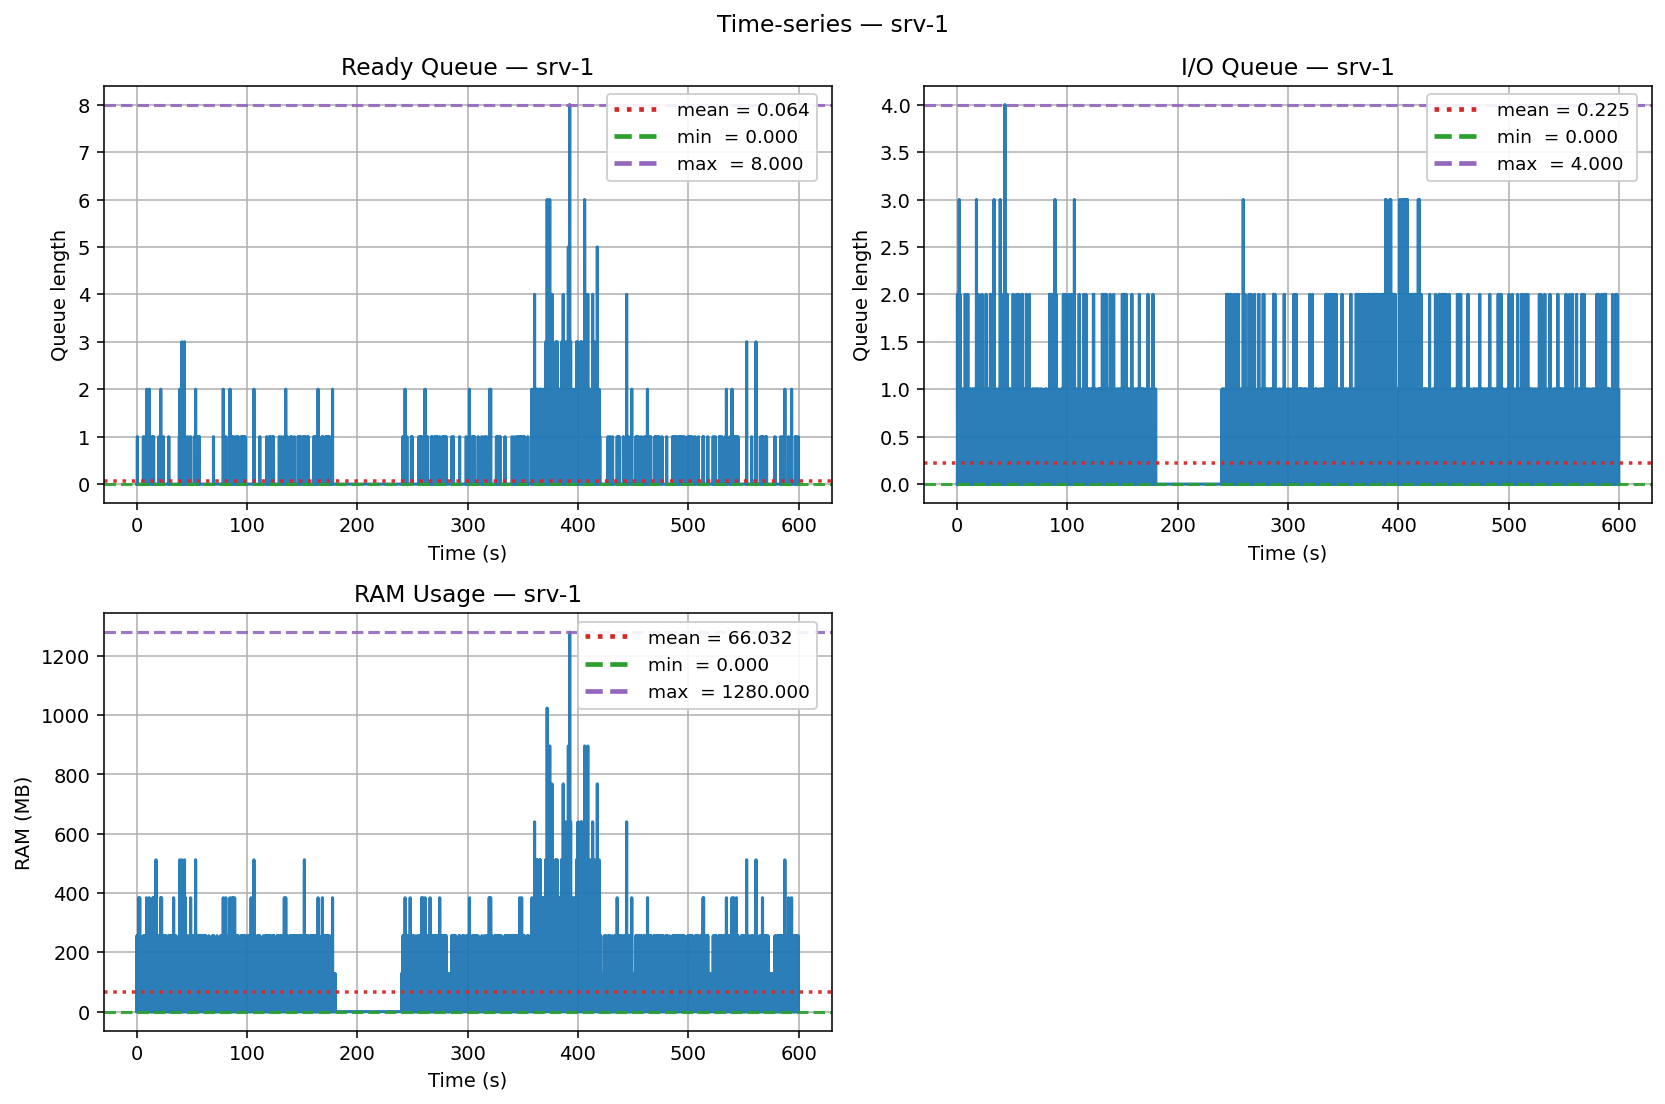

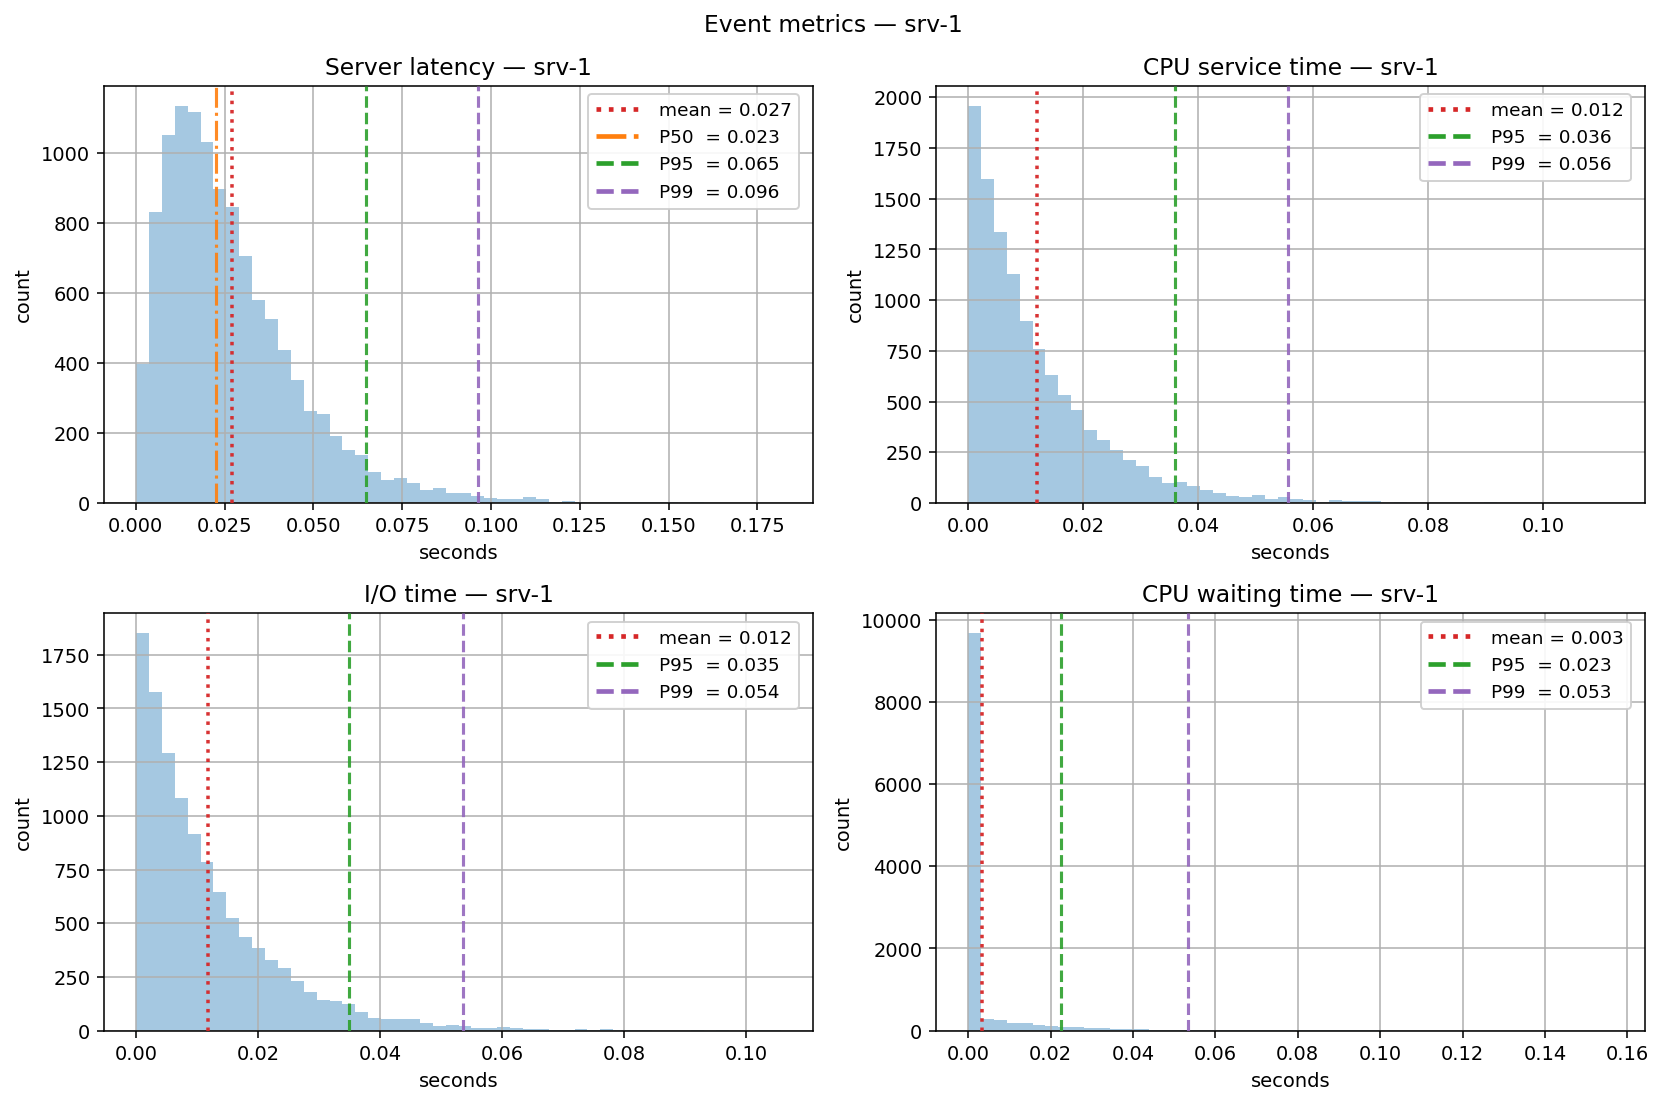

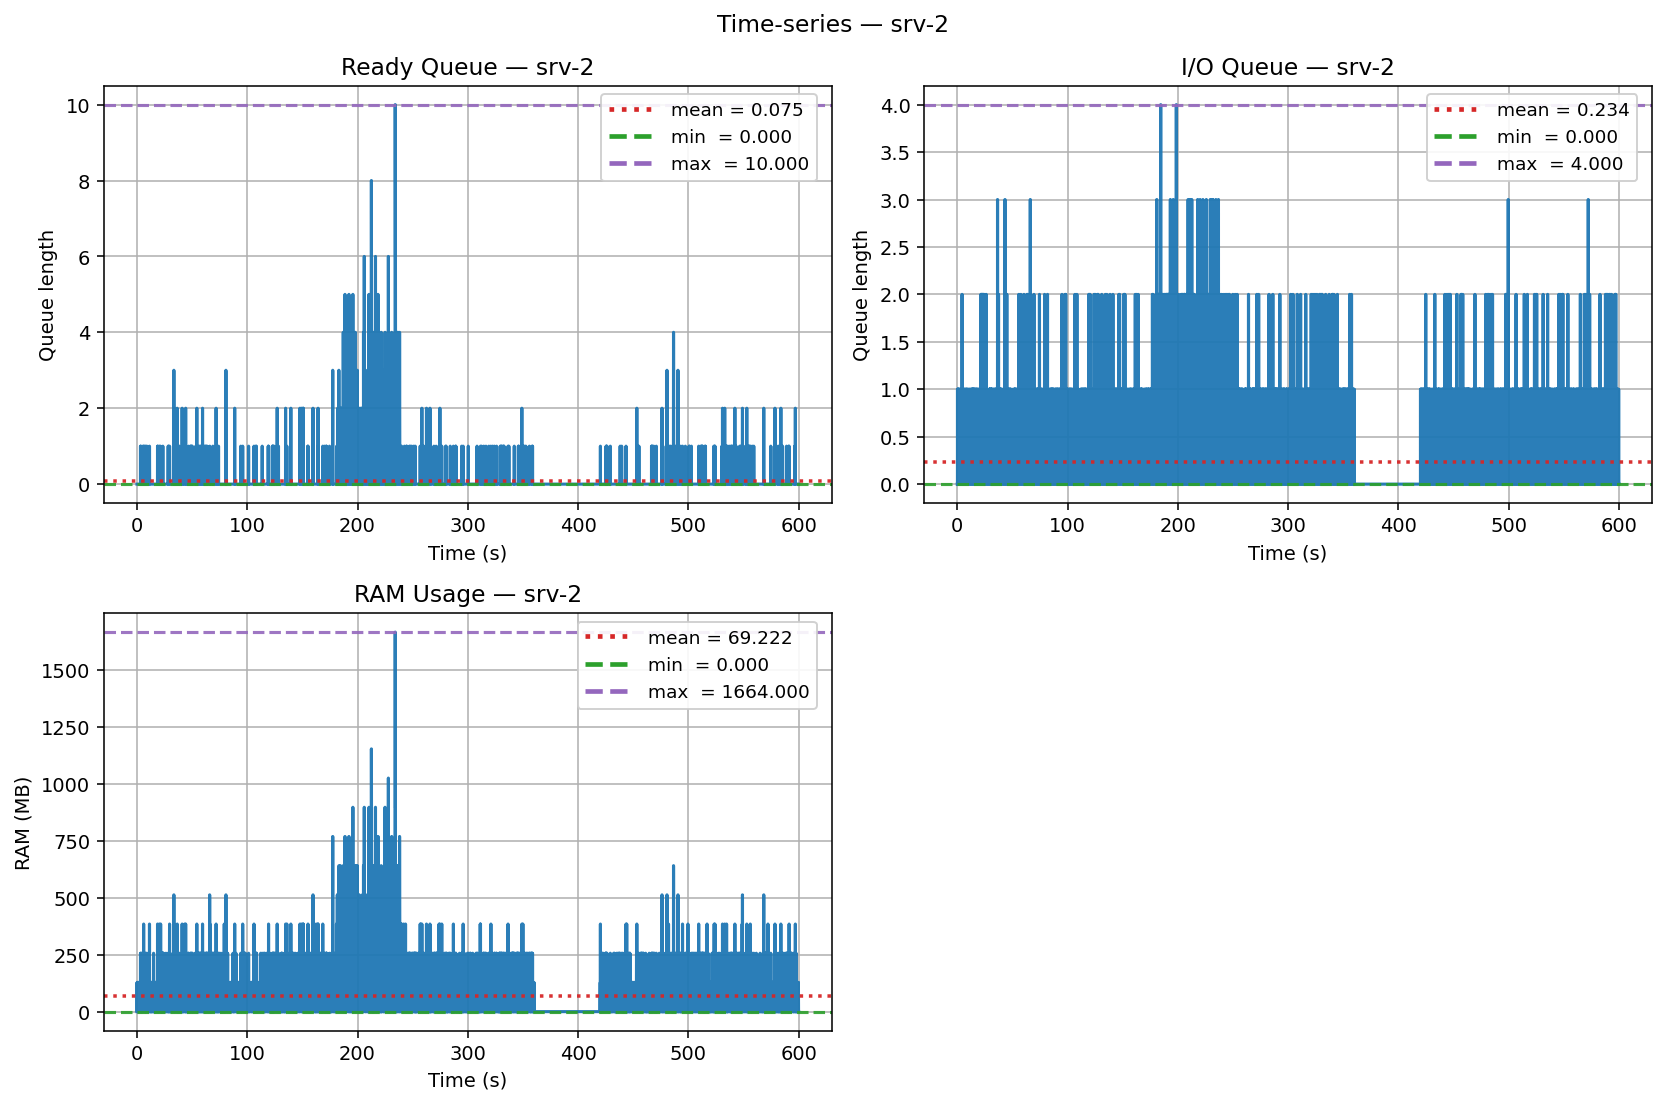

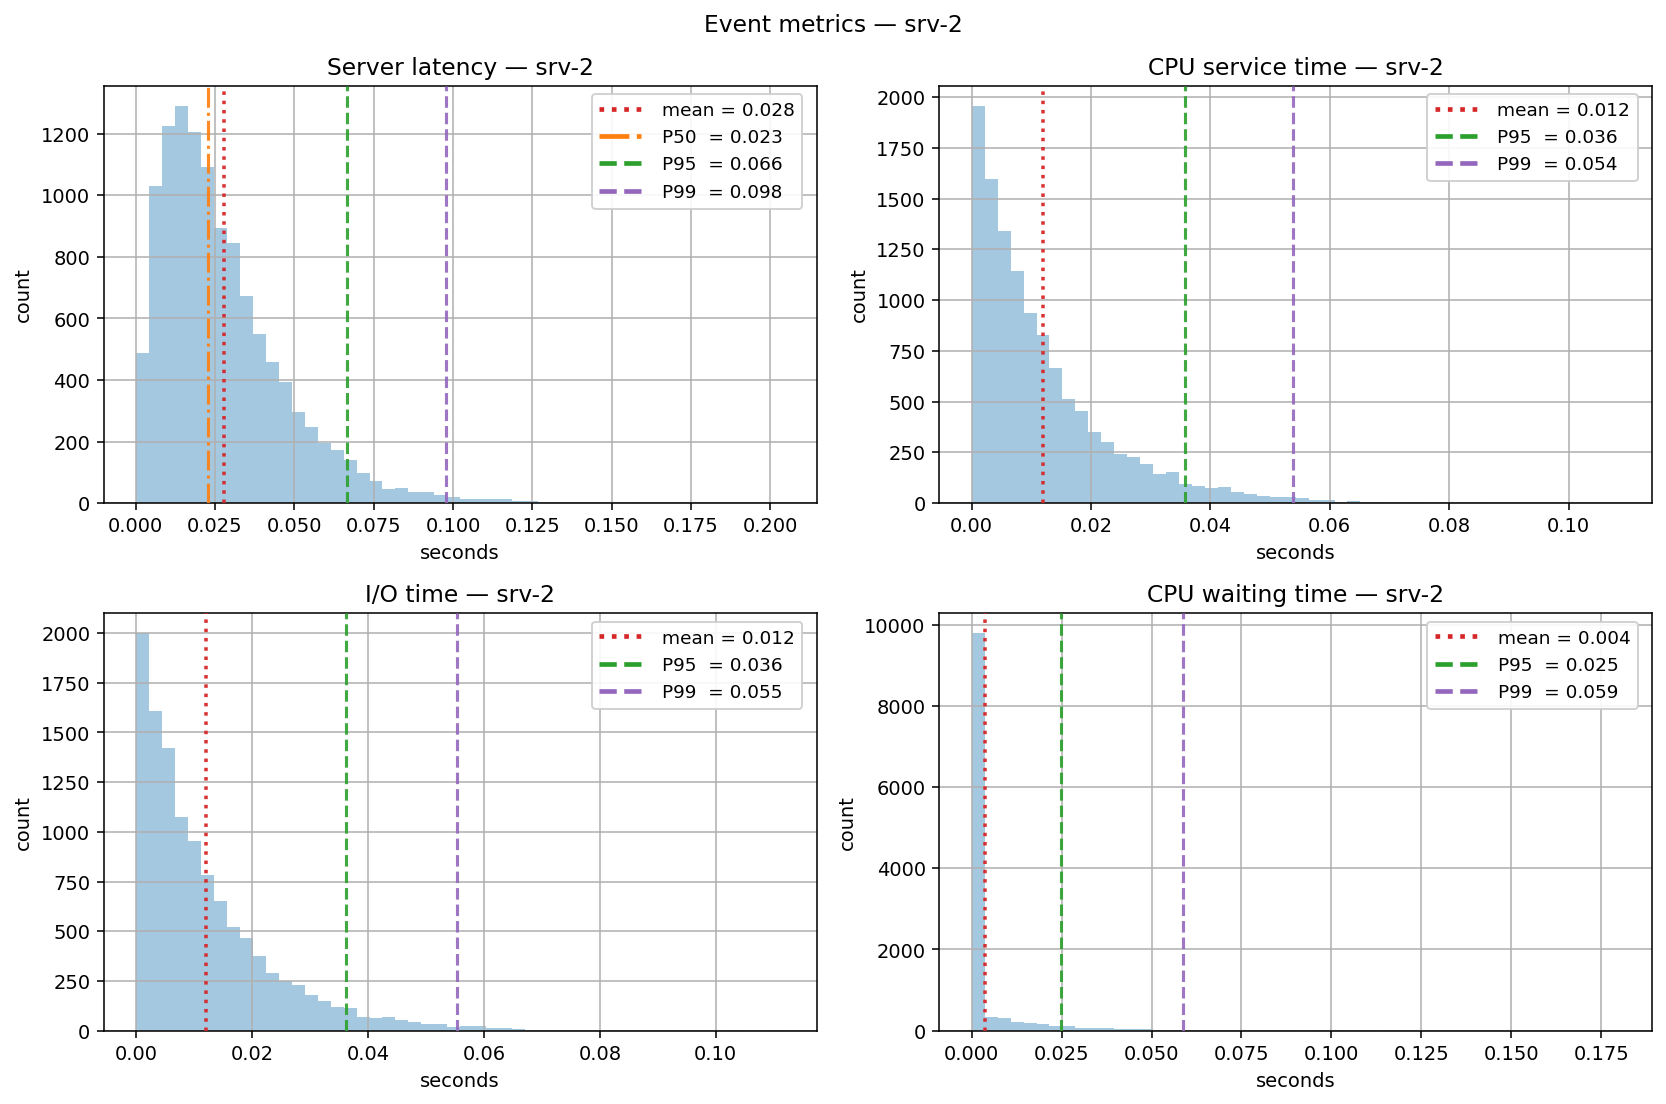

In [8]:
# 4.1 System dashboard: latency + throughput
fig_sys, axes_sys = plt.subplots(1, 2, figsize=(12, 4.5), dpi=140)
results.plot_latency_distribution(axes_sys[0])
results.plot_throughput(axes_sys[1])
fig_sys.tight_layout()
plt.show()

# 4.2 Server time-series and event-metric dashboards
sids = results.list_server_ids()
for sid in sids:
    # --- dashboards ---
    fig_ts, axes_ts = plt.subplots(2, 2, figsize=(12, 8), dpi=140)
    axes_ts[1, 1].axis("off")
    results.plot_server_timeseries_dashboard(
        ax_ready=axes_ts[0, 0],
        ax_io=axes_ts[0, 1],
        ax_ram=axes_ts[1, 0],
        server_id=sid,
    )
    fig_ts.suptitle(f"Time-series — {sid}")
    fig_ts.tight_layout()
    plt.show()

    fig_ev, axes_ev = plt.subplots(2, 2, figsize=(12, 8), dpi=140)
    results.plot_server_event_metrics_dashboard(
        ax_latency_hist=axes_ev[0, 0],
        ax_service_hist=axes_ev[0, 1],
        ax_io_hist=axes_ev[1, 0],
        ax_wait_hist=axes_ev[1, 1],
        server_id=sid,
    )
    fig_ev.suptitle(f"Event metrics — {sid}")
    fig_ev.tight_layout()
    plt.show()

